### Data prep

vamos a unir todos los datos en un solo data set en un archivo binario ligero para poder subirlo al repo

In [1]:
import pandas as pd

df1 = pd.read_csv("./data/1.csv")
df2 = pd.read_csv("./data/2.csv")
df3 = pd.read_csv("./data/3.csv")


In [2]:
df1["n_layers"] = 2
df2["n_layers"] = 2
df3["n_layers"] = 1
df = pd.concat([df1, df2, df3], ignore_index=True)
df.to_parquet("./data/data.parquet", index=False)

In [3]:
print(list(df.columns))

['experiment_id', 'precision', 'bits', 'hidden_size', 'n_hidden_layers', 'episodes_trained', 'stopped_early', 'best_episode', 'best_mean_reward', 'best_eval_reward', 'best_eval_episode', 'latency_mean_ms', 'latency_p50_ms', 'latency_p95_ms', 'latency_n_samples', 'throughput_pps', 'throughput_batch_size', 'params', 'packed_size_mb', 'flops', 'effective_capacity_bits', 'avg_steps', 'norm_reward', 'eval_episodes', 'eval_mean_reward', 'eval_makespan', 'eval_sla_violations', 'eval_sla_rate', 'wall_clock_s', 'device', 'seed', 'notes', 'extra', 'n_layers']


### Desempeno vs tamano

Ahora el analisis de interes es encontrar algun tipo de relacion entre los tamanos del modelo y las diferentes metricas de desempeno para los mismos. Para tener una metrica unificada para el tamano del modelo simplemente se va a multiplicar Capaz x numeros de neuronas x tamano de los pesos, no se usara el peso de los modelos como tal porque pueden existir algun tipo de optimizacion, digamos que es mas directo de esta manera. 

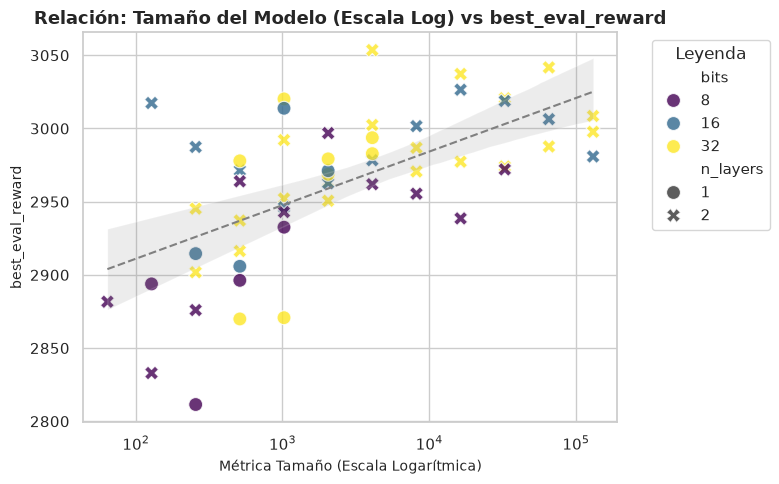

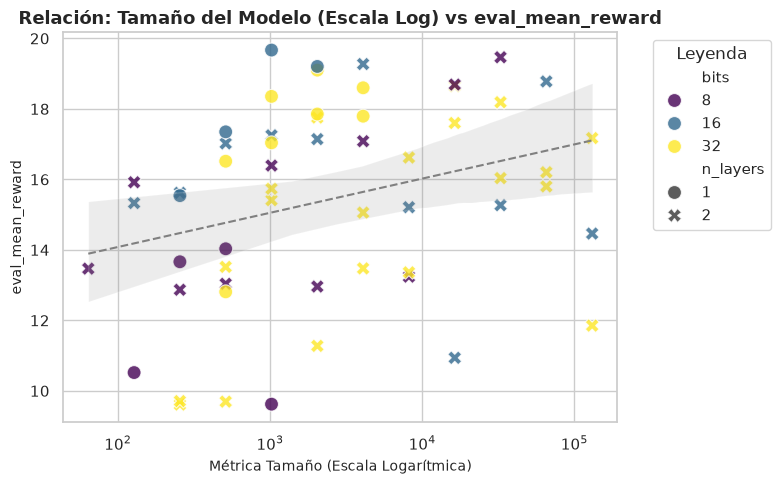

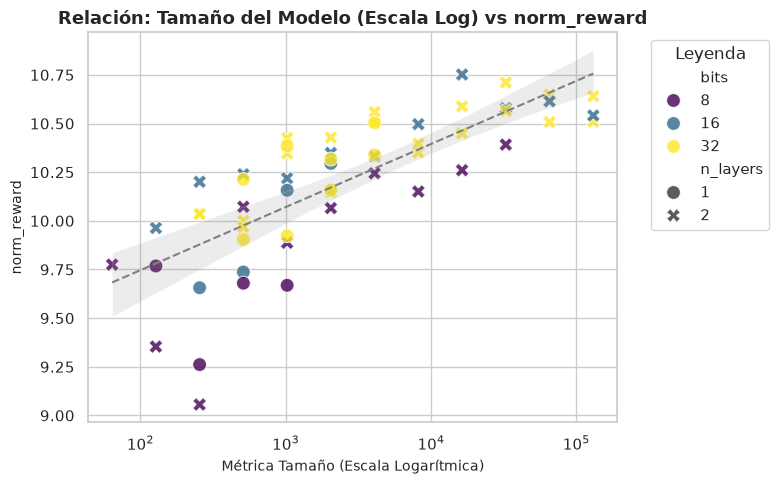

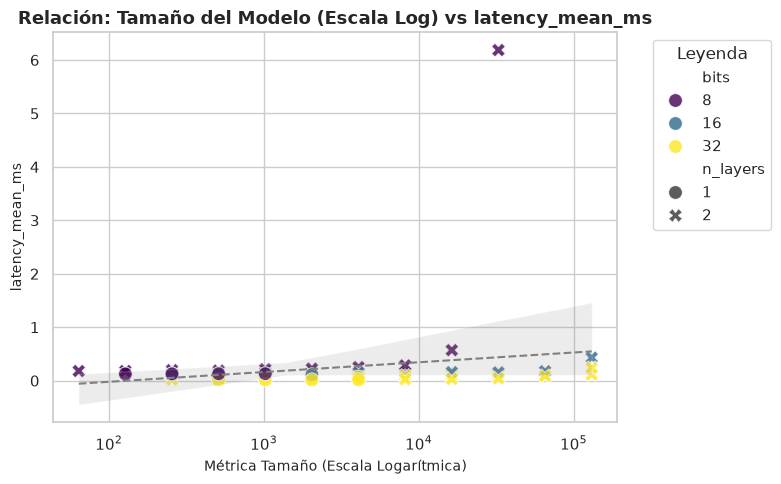

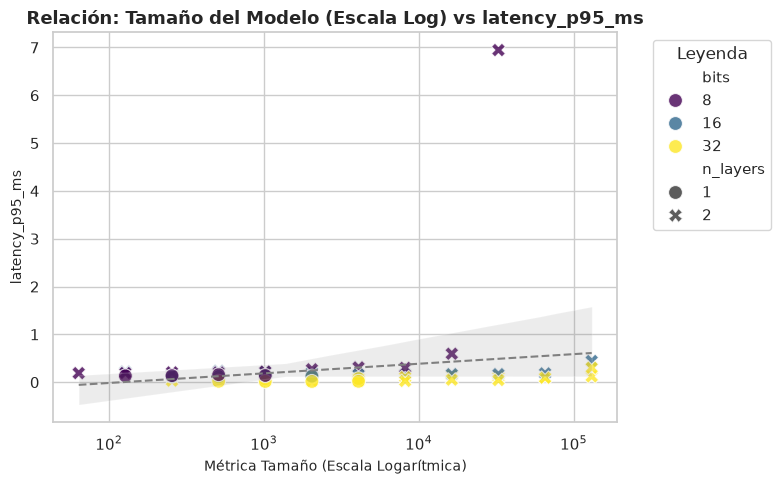

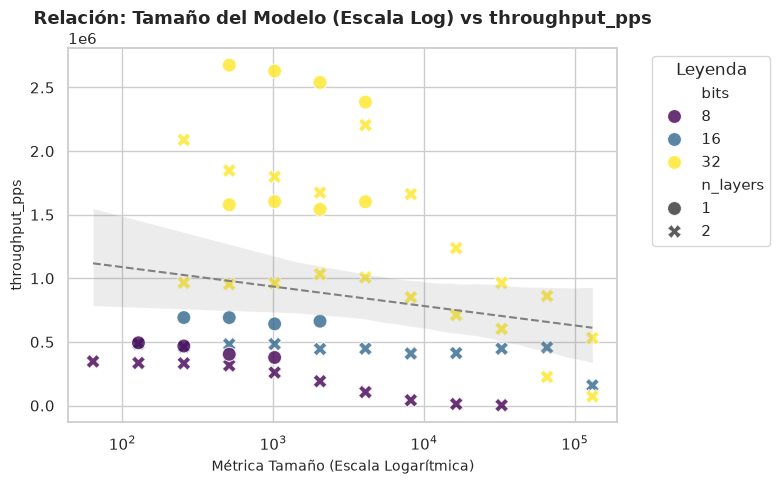

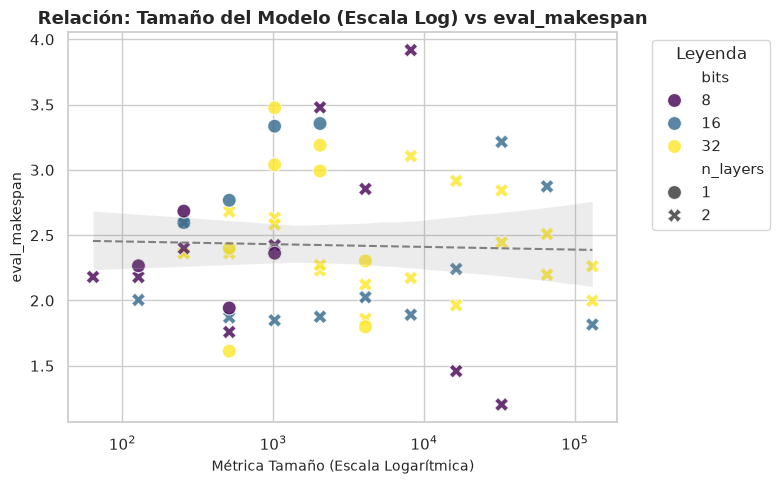

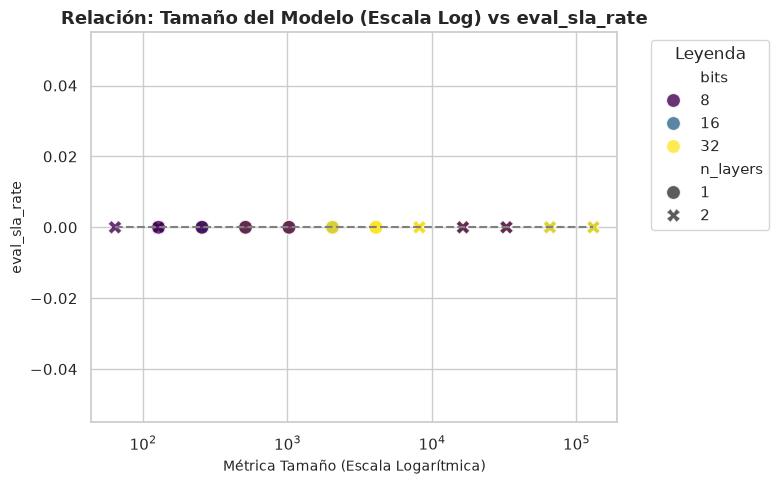

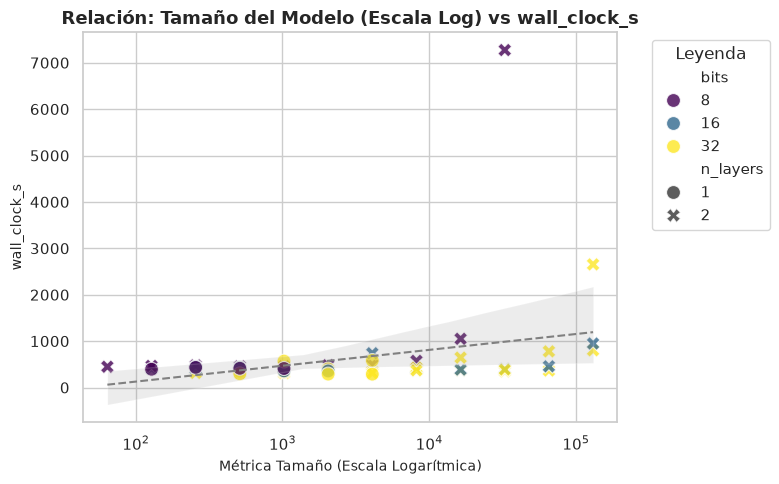

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

df["model_size_metric"] = df["n_layers"] * df["hidden_size"] * df["bits"]

# 3. Definir la lista de métricas de desempeño que deseas evaluar
performance_metrics = [
    "best_eval_reward",
    "eval_mean_reward",
    "norm_reward",
    "latency_mean_ms",
    "latency_p95_ms",
    "throughput_pps",
    "eval_makespan",
    "eval_sla_rate",
    "wall_clock_s",
]

sns.set_theme(style="whitegrid")

# 4. Generar una gráfica individual por cada métrica
for metric in performance_metrics:
    plt.figure(figsize=(8, 5))

    # Gráfico de dispersión
    sns.scatterplot(
        data=df,
        x="model_size_metric",
        y=metric,
        hue="bits",  # Diferencia los puntos por cuantización (bits)
        style="n_layers",  # Diferencia el estilo según las capas (1 vs 2)
        palette="viridis",
        s=100,
        alpha=0.8,
    )

    # Línea de tendencia ajustada a la escala logarítmica
    sns.regplot(
        data=df,
        x="model_size_metric",
        y=metric,
        scatter=False,
        logx=True,  
        color="gray",
        line_kws={"linestyle": "--", "linewidth": 1.5},
    )

    plt.xscale("log") 

    plt.title(
        f"Relación: Tamaño del Modelo (Escala Log) vs {metric}",
        fontsize=13,
        fontweight="bold",
    )
    plt.xlabel("Métrica Tamaño (Escala Logarítmica)", fontsize=10)
    plt.ylabel(metric, fontsize=10)
    plt.legend(title="Leyenda", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()

    plt.show()

In [7]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import statsmodels.api as sm

# 1. Crear la métrica logarítmica en el DataFrame
df["log_model_size"] = np.log(df["model_size_metric"])

results = []

for metric in performance_metrics:
    if metric not in df.columns:
        continue

    # Filtrar valores nulos
    clean_df = df[["log_model_size", metric]].dropna()

    X_log = clean_df["log_model_size"]
    y = clean_df[metric]

    # --- Regresión Lineal (OLS) ---
    X_ols = sm.add_constant(X_log)
    model = sm.OLS(y, X_ols).fit()

    # --- Correlación de Pearson ---
    r_pearson, p_val_pearson = pearsonr(X_log, y)

    results.append(
        {
            "Métrica (y)": metric,
            "Pearson (r)": r_pearson,
            "Pendiente (β1)": model.params["log_model_size"],
            "Intersección (β0)": model.params["const"],
            "R²": model.rsquared,
            "R² Ajustado": model.rsquared_adj,
            "p-value (β1 OLS)": model.pvalues["log_model_size"],
            "Error Estándar": model.bse["log_model_size"],
        }
    )

# 2. Crear el DataFrame resumen
df_regression = pd.DataFrame(results)

# Redondear valores numéricos para facilitar la lectura
df_regression = df_regression.round(5)

# Mostrar la tabla en pantalla
print(df_regression.to_string(index=False))

     Métrica (y)  Pearson (r)  Pendiente (β1)  Intersección (β0)      R²  R² Ajustado  p-value (β1 OLS)  Error Estándar
best_eval_reward      0.61554        15.88825       2.837861e+03 0.37889      0.36760           0.00000         2.74296
eval_mean_reward      0.30051         0.42156       1.213881e+01 0.09031      0.07377           0.02313         0.18041
     norm_reward      0.76941         0.14079       9.097820e+00 0.59199      0.58457           0.00000         0.01576
 latency_mean_ms      0.19654         0.07935      -3.872200e-01 0.03863      0.02115           0.14283         0.05338
  latency_p95_ms      0.19294         0.08738      -4.194800e-01 0.03722      0.01972           0.15046         0.05992
  throughput_pps     -0.18409    -66406.46916       1.394116e+06 0.03389      0.01633           0.17043     47808.18396
   eval_makespan     -0.03281        -0.00903       2.493480e+00 0.00108     -0.01709           0.80853         0.03708
   eval_sla_rate          NaN         0.

/tmp/ipykernel_153859/4151255878.py:26: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_pearson, p_val_pearson = pearsonr(X_log, y)
/home/turing/Documents/Markuves/d2ql/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:2018: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr / self.centered_tss


parece que no hay relaciones significativas para throughput y latencia, pero probablemente vale la pena separar CPU y CUDA, pues probablemente al trabajar con esta escala de modelos el overhead, especialmente de GPU no permitira ver claramente las tendencias

In [ ]:


# 1. Asegurar la variable logarítmica del tamaño
df["log_model_size"] = np.log(df["model_size_metric"])

# Métricas específicas de interés
target_metrics = [
    "latency_mean_ms",
    "latency_p95_ms",
    "throughput_pps",
    "wall_clock_s",
]

results = []

# Iterar por dispositivo (CPU vs CUDA) y por métrica
for device in df["device"].unique():
    df_device = df[df["device"] == device]

    for metric in target_metrics:
        if metric not in df_device.columns:
            continue

        clean_df = df_device[["log_model_size", metric]].dropna()

        # Si hay menos de 3 puntos no se puede hacer una regresión válida
        if len(clean_df) < 3:
            continue

        X_log = clean_df["log_model_size"]
        y = clean_df[metric]

        # Regresión OLS
        X_ols = sm.add_constant(X_log)
        model = sm.OLS(y, X_ols).fit()

        # Correlación de Pearson
        r_pearson, p_val_pearson = pearsonr(X_log, y)

        results.append(
            {
                "Device": device,
                "Métrica (y)": metric,
                "Pearson (r)": r_pearson,
                "Pendiente (β1)": model.params["log_model_size"],
                "Intersección (β0)": model.params["const"],
                "R²": model.rsquared,
                "R² Ajustado": model.rsquared_adj,
                "p-value (β1 OLS)": model.pvalues["log_model_size"],
                "Error Estándar": model.bse["log_model_size"],
            }
        )

# Crear el DataFrame estructurado
df_device_regression = pd.DataFrame(results).round(5)

# Mostrar la tabla ordenada por Métrica y Dispositivo
df_device_regression = df_device_regression.sort_values(
    by=["Métrica (y)", "Device"]
)
print(df_device_regression.to_string(index=False))

Device     Métrica (y)  Pearson (r)  p-value (Pearson)  Pendiente (β1)  Intersección (β0)      R²  R² Ajustado  p-value (β1 OLS)  Error Estándar
   cpu latency_mean_ms      0.28788            0.13740         0.16542      -9.109700e-01 0.08288      0.04760           0.13740         0.10792
  cuda latency_mean_ms      0.35225            0.06092         0.01183       3.274000e-02 0.12408      0.09164           0.06092         0.00605
   cpu  latency_p95_ms      0.29063            0.13353         0.18745      -1.036920e+00 0.08446      0.04925           0.13353         0.12104
  cuda  latency_p95_ms      0.22019            0.25107         0.00787       8.517000e-02 0.04848      0.01324           0.25107         0.00671
   cpu  throughput_pps     -0.15509            0.43067    -73325.14170       1.531321e+06 0.02405     -0.01348           0.43067     91598.91665
  cuda  throughput_pps     -0.25117            0.18875    -49656.47464       1.177327e+06 0.06309      0.02839           0.18875  